# Interaction summary JSONL → grouped MRR plot

This notebook loads your **interaction prediction `summary.jsonl`**, parses the run names, aggregates results across seeds, and makes the grouped bar plot in the same style as your earlier analysis.

### What it expects
- one row per finished run in `summary.jsonl`
- columns like `dataset`, `run` or `name`, `seed`, `best_val_mrr`, `best_snapshot`, `final_snapshot`, `wall_sec`
- run strings that contain pieces like `agg=...|update=...|do=...|sdo=...|time=...`

If your file path changes, just edit the config cell below.

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

plt.rcParams["figure.dpi"] = 140
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# -----------------------------
# config
# -----------------------------
SUMMARY_PATH = Path("/home/akapociu/ift/interactiondynamics/results/interaction_predictions_clean_all_models/summary.jsonl")
PLOTS_DIR = Path("/home/akapociu/ift/interactiondynamics/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# explicit combo ordering for the grouped plot
AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

# preferred 4-panel order for the old JODIE sweep plot
PREFERRED_DATASET_ORDER = ["Wikipedia", "Reddit", "MOOC", "LastFM"]

# if you want to require a full seed count for a combo, set this.
# purely informational here; the plot still shows whatever exists.
EXPECTED_SEEDS = 3

# filename for saved figure
PLOT_FILENAME = "grouped_by_aggregator_bar_with_incomplete_from_summary.png"

In [3]:
# -----------------------------
# helpers
# -----------------------------

def read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def safe_get(obj, *keys, default=np.nan):
    cur = obj
    for key in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(key)
        if cur is None:
            return default
    return cur


def maybe_cast(v):
    if isinstance(v, (bool, int, float)) or v is None:
        return v
    s = str(v).strip()
    if s.lower() == "true":
        return True
    if s.lower() == "false":
        return False
    try:
        if re.fullmatch(r"[-+]?\d+", s):
            return int(s)
        if re.fullmatch(r"[-+]?(?:\d*\.\d+|\d+\.\d*)(?:[eE][-+]?\d+)?", s):
            return float(s)
    except Exception:
        pass
    return s


def parse_run_string(run_name: str | None) -> dict:
    out = {
        "config_name": run_name,
        "aggregator": None,
        "update": None,
        "dropout": np.nan,
        "scorer_dropout": np.nan,
        "use_time_features": None,
    }

    if run_name is None or (isinstance(run_name, float) and math.isnan(run_name)):
        return out

    parts = str(run_name).split("|")
    extras = []

    for part in parts:
        if "=" in part:
            key, value = part.split("=", 1)
            key = key.strip()
            value = maybe_cast(value.strip())

            # handles things like "Wikipedia_agg=sum"
            if key.endswith("agg"):
                out["aggregator"] = str(value)
            elif key == "update":
                out["update"] = str(value)
            elif key == "do":
                out["dropout"] = float(value)
            elif key == "sdo":
                out["scorer_dropout"] = float(value)
            elif key == "time":
                out["use_time_features"] = bool(value)
            else:
                out[key] = value
        else:
            extras.append(part.strip())

    if extras:
        out["extra_parts"] = tuple(x for x in extras if x)

    return out


def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)


def pretty_name(agg, upd):
    agg_map = {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }
    upd_map = {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }
    return f"{agg_map.get(agg, agg)} / {upd_map.get(upd, upd)}"

In [4]:
# -----------------------------
# load + flatten summary rows
# -----------------------------
summary = read_jsonl(SUMMARY_PATH)
print("summary shape:", summary.shape)
display(summary.head(3))

run_col = "run" if "run" in summary.columns else "name"
summary["run_name"] = summary[run_col]

parsed = summary["run_name"].apply(parse_run_string).apply(pd.Series)
summary_df = pd.concat([summary.copy(), parsed], axis=1)

summary_df["best_test_mrr"] = summary_df["best_snapshot"].apply(lambda d: safe_get(d, "test", "mrr"))
summary_df["final_test_mrr"] = summary_df["final_snapshot"].apply(lambda d: safe_get(d, "test", "mrr"))
summary_df["final_val_mrr"] = summary_df["final_snapshot"].apply(lambda d: safe_get(d, "val", "mrr"))
summary_df["best_train_eval_mrr"] = summary_df["best_snapshot"].apply(lambda d: safe_get(d, "train_eval", "mrr"))
summary_df["final_train_eval_mrr"] = summary_df["final_snapshot"].apply(lambda d: safe_get(d, "train_eval", "mrr"))
summary_df["overfit_gap"] = summary_df["best_val_mrr"] - summary_df["best_test_mrr"]
summary_df["val_drop"] = summary_df["best_val_mrr"] - summary_df["final_val_mrr"]
summary_df["peaked_early"] = summary_df["best_epoch"].fillna(9999) <= 2

preferred_cols = [
    "dataset", "seed", "run_name", "aggregator", "update",
    "dropout", "scorer_dropout", "use_time_features",
    "best_val_mrr", "best_test_mrr", "final_test_mrr", "best_epoch", "wall_sec",
]

display(summary_df[[c for c in preferred_cols if c in summary_df.columns]].head(10))

summary shape: (171, 9)


,dataset,run,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec
0,charged_particles,charged_particles_agg=ift|update=ift_update|do...,0,6,1.0,1,"{'epoch': 1, 'train_step': {'loss': 3.04452228...","{'epoch': 6, 'train_step': {'loss': 3.04452228...",31.306523
1,charged_particles,charged_particles_agg=ift|update=tgn_gru|do=0....,0,6,1.0,1,"{'epoch': 1, 'train_step': {'loss': 3.04452228...","{'epoch': 6, 'train_step': {'loss': 3.04452228...",24.763814
2,charged_particles,charged_particles_agg=ift|update=lnn|do=0.0|sd...,0,6,1.0,1,"{'epoch': 1, 'train_step': {'loss': 3.04452228...","{'epoch': 6, 'train_step': {'loss': 3.04452228...",40.323894


,dataset,seed,run_name,aggregator,update,dropout,scorer_dropout,use_time_features,best_val_mrr,best_test_mrr,final_test_mrr,best_epoch,wall_sec
0,charged_particles,0,charged_particles_agg=ift|update=ift_update|do...,ift,ift_update,0.0,0.0,False,1.0,1.0,1.0,1,31.306523
1,charged_particles,0,charged_particles_agg=ift|update=tgn_gru|do=0....,ift,tgn_gru,0.0,0.0,False,1.0,1.0,1.0,1,24.763814
2,charged_particles,0,charged_particles_agg=ift|update=lnn|do=0.0|sd...,ift,lnn,0.0,0.0,False,1.0,1.0,1.0,1,40.323894
3,charged_particles,0,charged_particles_agg=ift|update=hopfield_upda...,ift,hopfield_update,0.0,0.0,False,1.0,1.0,1.0,1,35.802933
4,charged_particles,0,charged_particles_agg=ift|update=hnn|do=0.0|sd...,ift,hnn,0.0,0.0,False,1.0,1.0,1.0,1,50.993380
5,charged_particles,0,charged_particles_agg=hopfield|update=tgn_gru|...,hopfield,tgn_gru,0.0,0.0,False,1.0,1.0,1.0,1,30.167401
6,charged_particles,0,charged_particles_agg=hopfield|update=lnn|do=0...,hopfield,lnn,0.0,0.0,False,1.0,1.0,1.0,1,43.189708
7,charged_particles,0,charged_particles_agg=hopfield|update=hopfield...,hopfield,hopfield_update,0.0,0.0,False,1.0,1.0,1.0,1,40.055173
8,charged_particles,0,charged_particles_agg=hopfield|update=hnn|do=0...,hopfield,hnn,0.0,0.0,False,1.0,1.0,1.0,1,55.814736
9,charged_particles,0,charged_particles_agg=settransformer|update=if...,settransformer,ift_update,0.0,0.0,False,1.0,1.0,1.0,1,48.364837


In [5]:
# -----------------------------
# aggregate across seeds by dataset / aggregator / update
# -----------------------------
rank_all = (
    summary_df
    .groupby(["dataset", "aggregator", "update"], dropna=False)
    .agg(
        n_seeds=("seed", "nunique"),
        avg_val_mrr=("best_val_mrr", "mean"),
        std_val_mrr=("best_val_mrr", "std"),
        avg_best_test_mrr=("best_test_mrr", "mean"),
        std_best_test_mrr=("best_test_mrr", "std"),
        avg_final_test_mrr=("final_test_mrr", "mean"),
        avg_best_epoch=("best_epoch", "mean"),
        avg_wall_sec=("wall_sec", "mean"),
        mean_overfit_gap=("overfit_gap", "mean"),
        mean_val_drop=("val_drop", "mean"),
        peaked_early_rate=("peaked_early", "mean"),
    )
    .reset_index()
)

rank_all["did_complete"] = rank_all["n_seeds"] == EXPECTED_SEEDS

rank_all_by_dataset = {
    ds: (
        rank_all[rank_all["dataset"] == ds]
        .sort_values(["avg_val_mrr", "avg_best_test_mrr"], ascending=False)
        .reset_index(drop=True)
    )
    for ds in sorted(summary_df["dataset"].dropna().unique())
}

for ds, df in rank_all_by_dataset.items():
    print(f"\n=== {ds} ===")
    display(df.head(10))


=== charged_particles ===


,dataset,aggregator,update,n_seeds,avg_val_mrr,std_val_mrr,avg_best_test_mrr,std_best_test_mrr,avg_final_test_mrr,avg_best_epoch,avg_wall_sec,mean_overfit_gap,mean_val_drop,peaked_early_rate,did_complete
0,charged_particles,deepsets,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,45.200885,0.0,0.0,1.0,False
1,charged_particles,deepsets,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,35.109277,0.0,0.0,1.0,False
2,charged_particles,deepsets,ift_update,1,1.0,NaN,1.0,NaN,1.0,1.0,29.740942,0.0,0.0,1.0,False
3,charged_particles,deepsets,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,35.330398,0.0,0.0,1.0,False
4,charged_particles,deepsets,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,24.476952,0.0,0.0,1.0,False
5,charged_particles,hopfield,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,55.814736,0.0,0.0,1.0,False
6,charged_particles,hopfield,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,40.055173,0.0,0.0,1.0,False
7,charged_particles,hopfield,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,43.189708,0.0,0.0,1.0,False
8,charged_particles,hopfield,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,30.167401,0.0,0.0,1.0,False
9,charged_particles,ift,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,50.993380,0.0,0.0,1.0,False



=== lastfm ===


,dataset,aggregator,update,n_seeds,avg_val_mrr,std_val_mrr,avg_best_test_mrr,std_best_test_mrr,avg_final_test_mrr,avg_best_epoch,avg_wall_sec,mean_overfit_gap,mean_val_drop,peaked_early_rate,did_complete
0,lastfm,deepsets,hopfield_update,1,1.000000,NaN,1.000000,NaN,1.000000,1.0,4537.615171,-2.067260e-10,0.000000,1.0,False
1,lastfm,deepsets,ift_update,1,1.000000,NaN,1.000000,NaN,1.000000,1.0,3384.284321,-2.067260e-10,0.000000,1.0,False
2,lastfm,settransformer,ift_update,1,1.000000,NaN,1.000000,NaN,1.000000,2.0,6659.101315,-2.067260e-10,0.000000,1.0,False
3,lastfm,ift,tgn_gru,1,0.434220,NaN,0.472254,NaN,0.454220,4.0,2782.421496,-3.803397e-02,0.013298,0.0,False
4,lastfm,sum,hopfield_update,1,0.431644,NaN,0.459315,NaN,0.407953,3.0,3777.750134,-2.767156e-02,0.045709,0.0,False
5,lastfm,ift,hopfield_update,1,0.428507,NaN,0.460560,NaN,0.279477,3.0,4578.124688,-3.205309e-02,0.166898,0.0,False
6,lastfm,sum,tgn_gru,1,0.428421,NaN,0.446489,NaN,0.404738,2.0,2479.285276,-1.806807e-02,0.056538,1.0,False
7,lastfm,ift,ift_update,1,0.427304,NaN,0.464665,NaN,0.464953,5.0,3371.478996,-3.736108e-02,0.001016,0.0,False
8,lastfm,hopfield,hopfield_update,1,0.422889,NaN,0.450419,NaN,0.441876,3.0,5768.146413,-2.752991e-02,0.009837,0.0,False
9,lastfm,hopfield,tgn_gru,1,0.401943,NaN,0.431685,NaN,0.406153,5.0,3354.163030,-2.974282e-02,0.035160,0.0,False



=== mooc ===


...

,dataset,aggregator,update,n_seeds,avg_val_mrr,std_val_mrr,avg_best_test_mrr,std_best_test_mrr,avg_final_test_mrr,avg_best_epoch,avg_wall_sec,mean_overfit_gap,mean_val_drop,peaked_early_rate,did_complete
0,springweb,deepsets,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,45.409737,0.0,0.0,1.0,False
1,springweb,deepsets,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,34.784432,0.0,0.0,1.0,False
2,springweb,deepsets,ift_update,1,1.0,NaN,1.0,NaN,1.0,1.0,29.536445,0.0,0.0,1.0,False
3,springweb,deepsets,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,35.638193,0.0,0.0,1.0,False
4,springweb,deepsets,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,24.248911,0.0,0.0,1.0,False
5,springweb,hopfield,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,56.078652,0.0,0.0,1.0,False
6,springweb,hopfield,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,40.012209,0.0,0.0,1.0,False
7,springweb,hopfield,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,43.423557,0.0,0.0,1.0,False
8,springweb,hopfield,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,30.075365,0.0,0.0,1.0,False
9,springweb,ift,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,51.079577,0.0,0.0,1.0,False



=== wave ===


,dataset,aggregator,update,n_seeds,avg_val_mrr,std_val_mrr,avg_best_test_mrr,std_best_test_mrr,avg_final_test_mrr,avg_best_epoch,avg_wall_sec,mean_overfit_gap,mean_val_drop,peaked_early_rate,did_complete
0,wave,deepsets,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,44.548763,0.0,0.0,1.0,False
1,wave,deepsets,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,34.077436,0.0,0.0,1.0,False
2,wave,deepsets,ift_update,1,1.0,NaN,1.0,NaN,1.0,1.0,28.907641,0.0,0.0,1.0,False
3,wave,deepsets,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,34.812623,0.0,0.0,1.0,False
4,wave,deepsets,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,23.668122,0.0,0.0,1.0,False
5,wave,hopfield,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,55.333274,0.0,0.0,1.0,False
6,wave,hopfield,hopfield_update,1,1.0,NaN,1.0,NaN,1.0,1.0,39.221580,0.0,0.0,1.0,False
7,wave,hopfield,lnn,1,1.0,NaN,1.0,NaN,1.0,1.0,42.687201,0.0,0.0,1.0,False
8,wave,hopfield,tgn_gru,1,1.0,NaN,1.0,NaN,1.0,1.0,29.469808,0.0,0.0,1.0,False
9,wave,ift,hnn,1,1.0,NaN,1.0,NaN,1.0,1.0,50.260591,0.0,0.0,1.0,False



=== wikipedia ===


,dataset,aggregator,update,n_seeds,avg_val_mrr,std_val_mrr,avg_best_test_mrr,std_best_test_mrr,avg_final_test_mrr,avg_best_epoch,avg_wall_sec,mean_overfit_gap,mean_val_drop,peaked_early_rate,did_complete
0,wikipedia,sum,hopfield_update,1,0.863662,NaN,0.863849,NaN,0.755124,5.0,399.370794,-0.000187,0.079580,0.0,False
1,wikipedia,ift,hopfield_update,1,0.861217,NaN,0.865397,NaN,0.837324,1.0,408.211722,-0.004180,0.032983,1.0,False
2,wikipedia,ift,tgn_gru,1,0.859837,NaN,0.865965,NaN,0.862324,2.0,48.431764,-0.006128,0.001855,1.0,False
3,wikipedia,settransformer,hopfield_update,1,0.856242,NaN,0.854800,NaN,0.854800,6.0,484.344370,0.001442,0.000000,0.0,False
4,wikipedia,deepsets,hopfield_update,1,0.846757,NaN,0.846418,NaN,0.846418,6.0,404.260379,0.000338,0.000000,0.0,False
5,wikipedia,sum,tgn_gru,1,0.844772,NaN,0.839776,NaN,0.758342,5.0,42.381717,0.004995,0.060350,0.0,False
6,wikipedia,settransformer,tgn_gru,1,0.828806,NaN,0.828437,NaN,0.828437,6.0,111.169670,0.000369,0.000000,0.0,False
7,wikipedia,hopfield,hopfield_update,1,0.828399,NaN,0.823465,NaN,0.823465,6.0,454.936311,0.004934,0.000000,0.0,False
8,wikipedia,hopfield,tgn_gru,1,0.823630,NaN,0.826926,NaN,0.817385,4.0,67.978966,-0.003296,0.005150,0.0,False
9,wikipedia,deepsets,tgn_gru,1,0.823455,NaN,0.815941,NaN,0.815941,6.0,48.380566,0.007514,0.000000,0.0,False


In [48]:
# -----------------------------
# choose exactly which datasets to show
# -----------------------------
# DATASET_ORDER = [
#     "Wikipedia",
#     "Reddit",
#     "MOOC",
#     "LastFM",
# ]
DATASET_ORDER = [
    "charged_particles",
    "wave",
    "springweb"
]

DATASET_ORDER = [item.lower() for item in DATASET_ORDER]

# optional safety check
seen = set(summary_df["dataset"].dropna().unique())
missing = [ds for ds in DATASET_ORDER if ds not in seen]
if missing:
    raise ValueError(f"These datasets were requested but not found in summary file: {missing}")

print("DATASET_ORDER:", DATASET_ORDER)

DATASET_ORDER: ['charged_particles', 'wave', 'springweb']


saved plot to: /home/akapociu/ift/interactiondynamics/plots/grouped_by_aggregator_bar_with_incomplete_from_summary.png


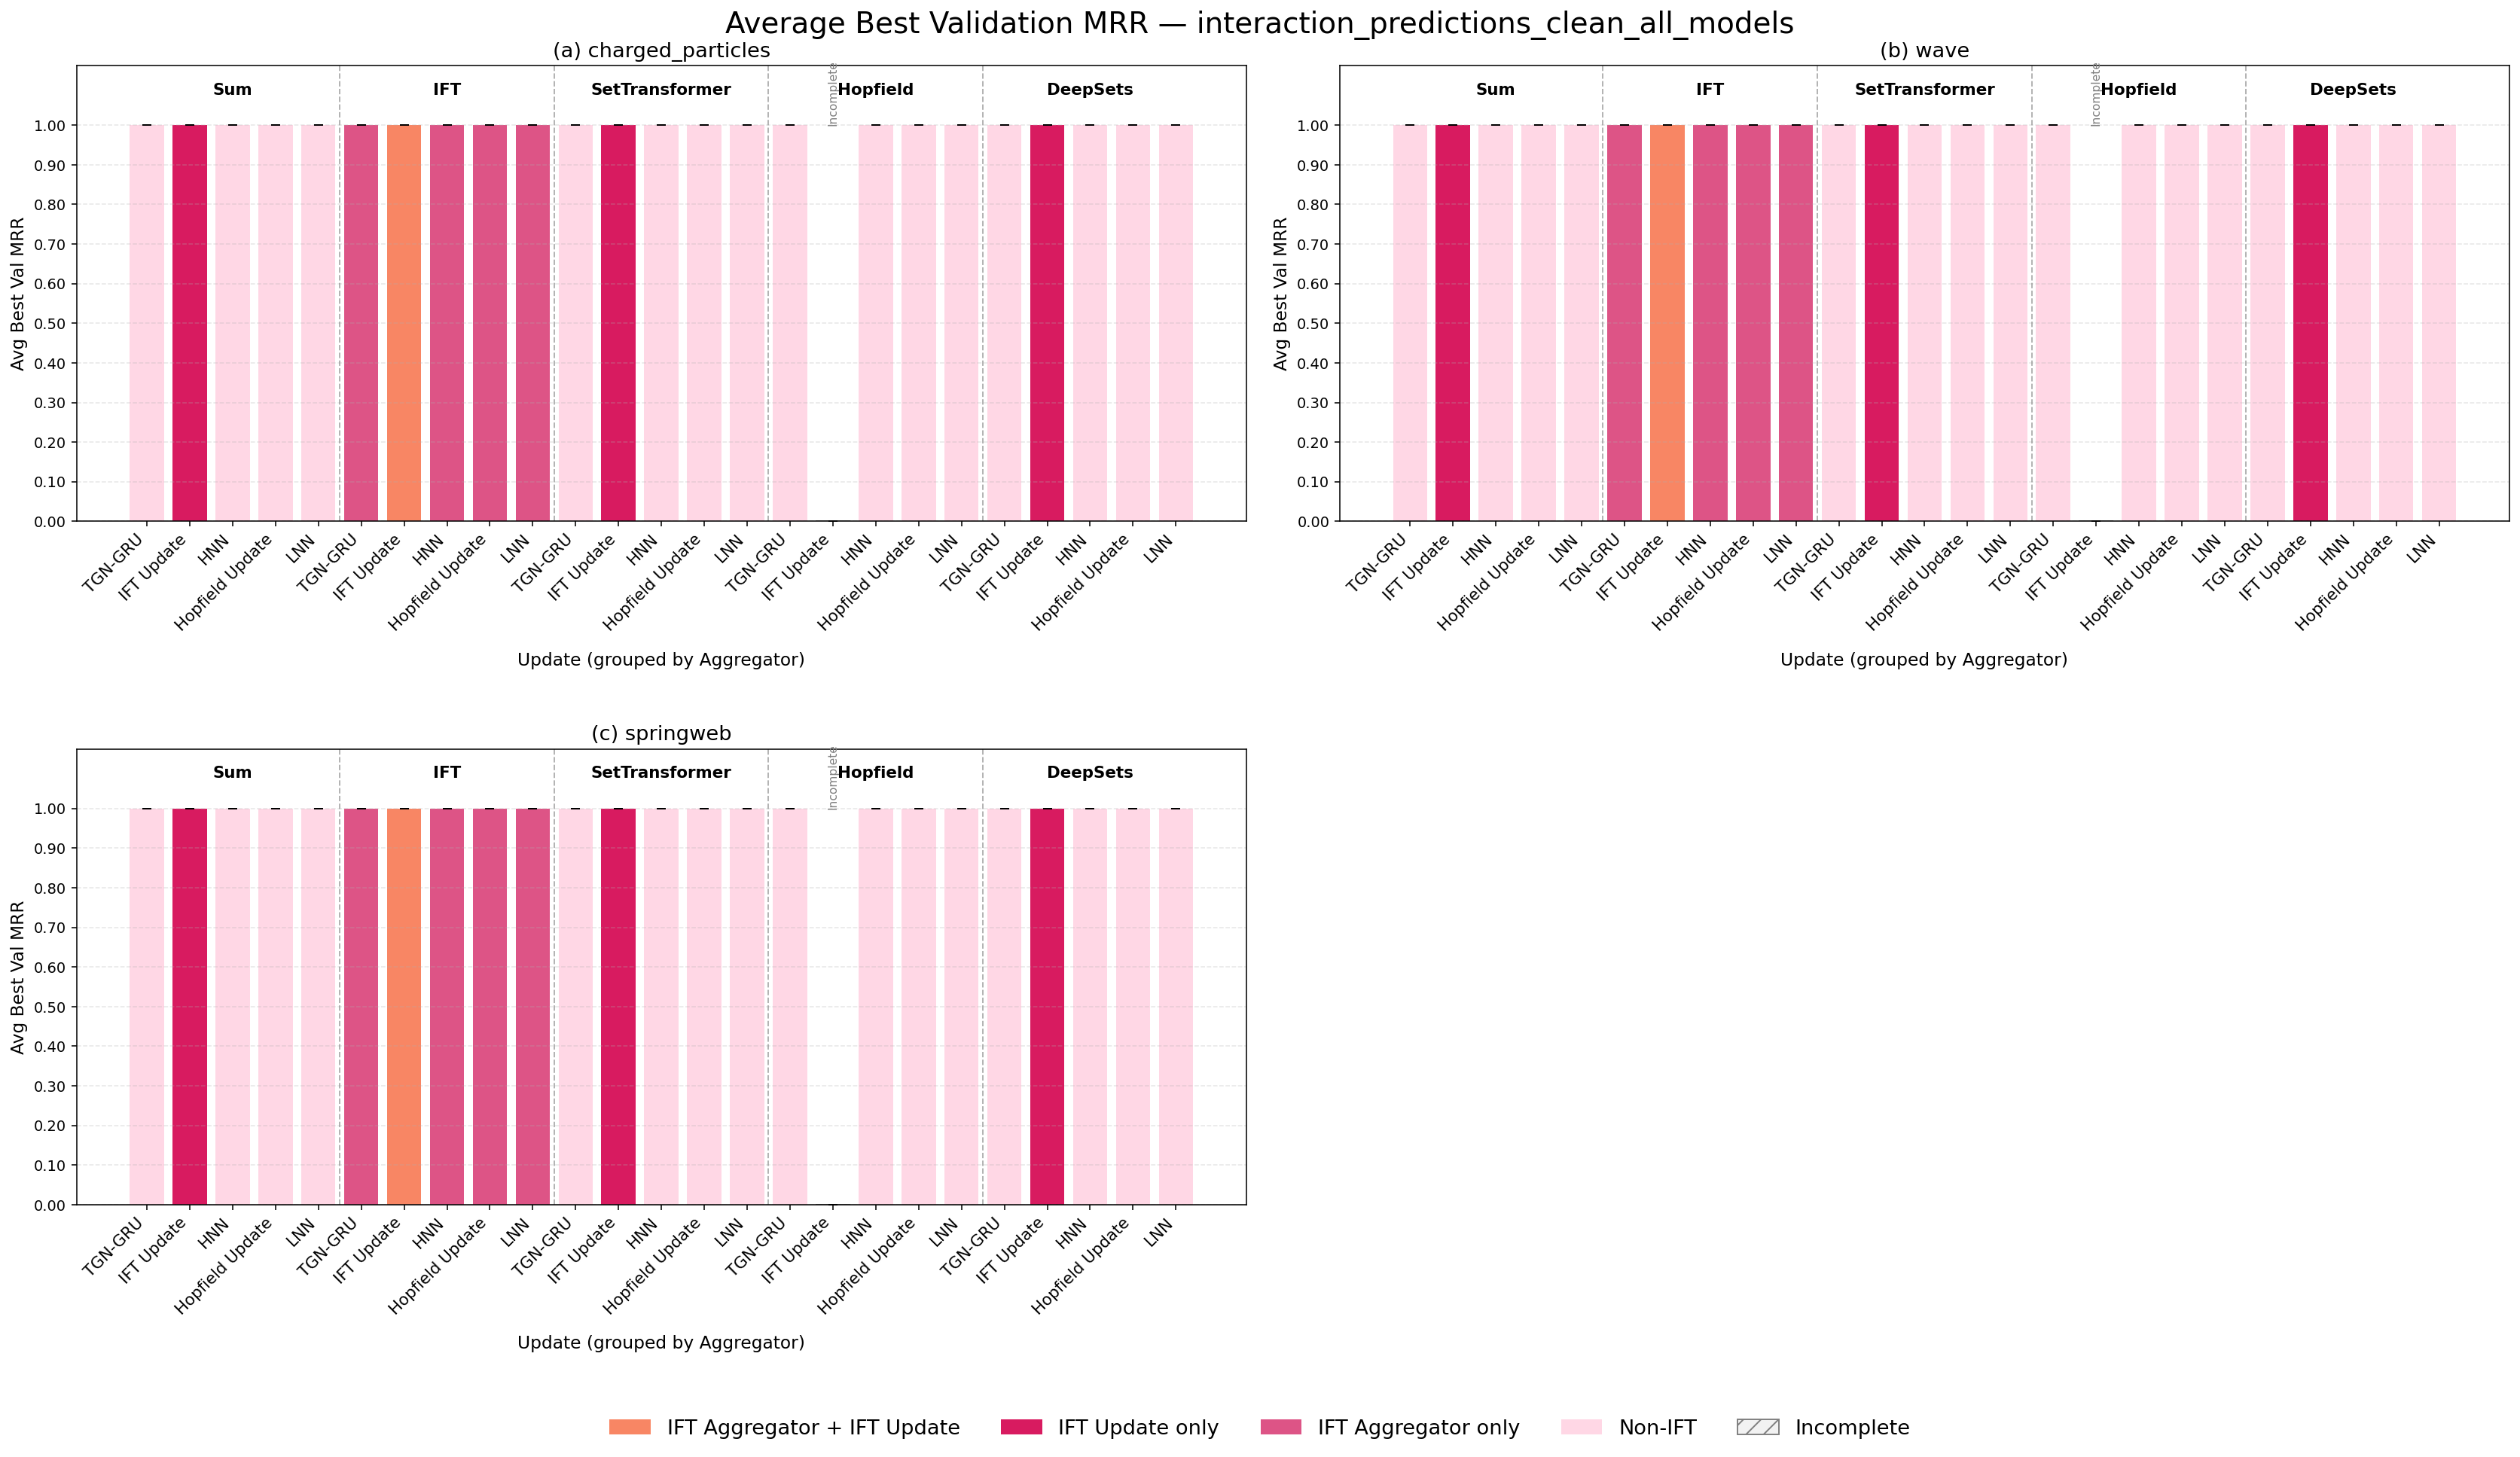

In [49]:
# -----------------------------
# grouped plot by aggregator block, update within block
# -----------------------------
labels_abcd = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)"]
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

n_panels = len(DATASET_ORDER)
fig, axes = plt.subplots(2, 2, figsize=(24, 14), sharey=False)
axes = axes.flatten()

for ax in axes[n_panels:]:
    ax.axis("off")

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    focus_df = rank_all_by_dataset[ds].copy()

    df_full = full_df.merge(focus_df, on=["aggregator", "update"], how="left")
    df_full["aggregator"] = pd.Categorical(df_full["aggregator"], categories=AGG_ORDER, ordered=True)
    df_full["update"] = pd.Categorical(df_full["update"], categories=UPD_ORDER, ordered=True)
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["avg_val_mrr"].values
    err = df_full["std_val_mrr"].fillna(0.0).values
    labels = [pretty_upd(u) for u in df_full["update"]]
    bar_heights = np.nan_to_num(y, nan=0.0)

    bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

    finite_y = y[np.isfinite(y)]
    if len(finite_y) > 0:
        y_min = float(np.min(finite_y))
        y_max = float(np.max(finite_y))
        y_span = max(y_max - y_min, 0.05)
        missing_text_y = max(0.01, y_min - 0.02 * y_span)
        top_label_y = y_max + 0.08 * y_span
        lower_ylim = max(0.0, y_min - 0.10 * y_span)
        upper_ylim = min(1.1, y_max + 0.18 * y_span)
    else:
        missing_text_y = 0.02
        top_label_y = 1.02
        lower_ylim = 0.0
        upper_ylim = 1.05

    for i, (bar, upd, agg, val) in enumerate(zip(bars, df_full["update"], df_full["aggregator"], y)):
        if pd.isna(val):
            bar.set_facecolor("#f2f2f2")
            bar.set_edgecolor("gray")
            bar.set_hatch("//")
            bar.set_linewidth(1.0)
            ax.text(
                i,
                missing_text_y,
                "Incomplete",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray",
            )
        else:
            if (upd == "ift_update") and (agg == "ift"):
                bar.set_facecolor("#f88664")
            elif upd == "ift_update":
                bar.set_facecolor("#d81b60")
            elif agg == "ift":
                bar.set_facecolor("#dd5486")
            else:
                bar.set_facecolor("#ffd7e5")

    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    group_centers = [2, 7, 12, 17, 22]
    group_names = ["Sum", "IFT", "SetTransformer", "Hopfield", "DeepSets"]
    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            1.07,
            gname,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    ax.set_title(f"{panel_label} {ds}", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Avg Best Val MRR", fontsize=12)
    ax.set_xlabel("Update (grouped by Aggregator)", fontsize=12, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    #ax.set_ylim(lower_ylim, upper_ylim)
    ax.set_ylim([0, 1.15])
    ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

legend_elements = [
    Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=14,
)
folder_name = SUMMARY_PATH.parent.name
fig.suptitle(f"Average Best Validation MRR — {folder_name}", fontsize=20)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.subplots_adjust(hspace=0.5, wspace=0.08)

plot_path = PLOTS_DIR / PLOT_FILENAME
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"saved plot to: {plot_path}")
plt.show()

In [8]:
# -----------------------------
# optional: export the ranking table used for the plot
# -----------------------------
ranking_csv_path = PLOTS_DIR / "interaction_summary_rankings.csv"
rank_all.sort_values(["dataset", "avg_val_mrr"], ascending=[True, False]).to_csv(ranking_csv_path, index=False)
print(f"saved ranking csv to: {ranking_csv_path}")

saved ranking csv to: /home/akapociu/ift/interactiondynamics/plots/interaction_summary_rankings.csv
